# 03 — Alignment & abnormal returns

Doel: posts ↔ marktdata koppelen, **abnormal returns** berekenen, en per post
voor elke (asset, window) combinatie de target-variabele opslaan.

**Plan:**
1. Load `posts.parquet` + `market.parquet` (output van notebooks 01 & 02).
2. Compute log returns + abnormal returns per ticker (rolling-mean baseline).
3. Compute multi-day cumulative abnormal returns (CAR) voor 3-day window.
4. Align elke post aan de **eerstvolgende trading day** via `merge_asof`.
5. Per post: target = AR_1d en CAR_3d voor elk asset.
6. Sanity check: AR-distributie op dagen *met* post vs. dagen *zonder* post.
7. Save `aligned.parquet` met (post_id, AR_1d_spx, CAR_3d_spx, AR_1d_wti, CAR_3d_wti, …).

**Methodologische keuzes (ter discussie met begeleider):**
- *Expected return*: simple rolling-mean over [t-30d, t-1d]. Market-model versie
  als robustness in week 5.
- *Time-of-day*: daily resolution. Post om 03:00 UTC → maandag close return.
  Intraday alignment is een extra robustheid voor later.
- *Multiple posts per dag*: target wordt herhaald per post (dus dag met 10 posts
  geeft 10 rijen met dezelfde AR). Alternatief = aggregeren naar dag-niveau.


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"pandas={pd.__version__}, numpy={np.__version__}")

pandas=3.0.2, numpy=2.4.4


## 1. Load data


In [2]:
posts = pd.read_parquet("../data/raw/posts.parquet")
market = pd.read_parquet("../data/raw/market.parquet")

# Defensive: timezone-aware dates
posts["timestamp_utc"] = pd.to_datetime(posts["timestamp_utc"], utc=True)
market["date"] = pd.to_datetime(market["date"], utc=True)

print(f"Posts:  {len(posts):,} rows, {posts['timestamp_utc'].min().date()} → {posts['timestamp_utc'].max().date()}")
print(f"Market: {len(market):,} rows, {market['date'].min().date()} → {market['date'].max().date()}")
print(f"Tickers: {sorted(market['ticker'].unique())}")

Posts:  26,819 rows, 2022-02-14 → 2026-04-23
Market: 4,378 rows, 2022-02-01 → 2026-06-11
Tickers: ['dxy', 'spx', 'vix', 'wti']


## 2. Abnormal returns per ticker

`AR(t) = log_return(t) − E[log_return(t)]`, waarbij E[·] = rolling 30-day mean
gemeten *vóór* t (geen look-ahead).


In [3]:
def compute_abnormal_returns(market: pd.DataFrame, window: int = 30) -> pd.DataFrame:
    df = market.sort_values(["ticker", "date"]).copy()
    df["log_return"] = df.groupby("ticker")["close"].transform(lambda s: np.log(s / s.shift(1)))
    # Expected return = rolling mean over voorbije N dagen, geshift om look-ahead te vermijden
    df["expected_return"] = df.groupby("ticker")["log_return"].transform(
        lambda s: s.rolling(window, min_periods=10).mean().shift(1)
    )
    df["abnormal_return"] = df["log_return"] - df["expected_return"]
    return df


market_ar = compute_abnormal_returns(market, window=30)
market_ar.groupby("ticker")["abnormal_return"].describe().round(5)

,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
dxy,1084.0,0.00001,0.00471,-0.02078,-0.00255,0.00014,0.00302,0.01556
spx,1081.0,0.00003,0.01114,-0.05743,-0.00546,-0.00023,0.00577,0.09684
vix,1083.0,-0.00006,0.07590,-0.47547,-0.03947,-0.00486,0.03372,0.56497
wti,1085.0,-0.00014,0.02647,-0.19705,-0.01446,0.00160,0.01555,0.10552


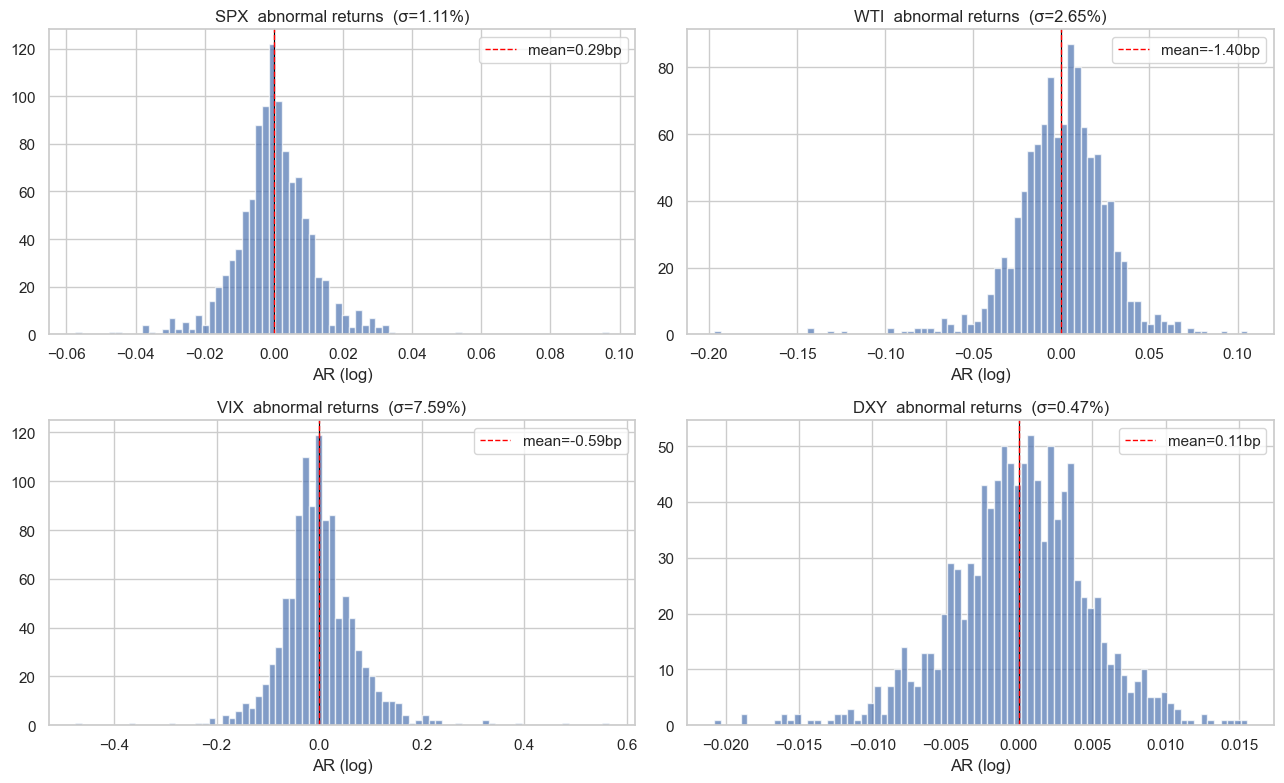

In [4]:
# Visualiseer AR-distributie per ticker
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, alias in zip(axes.flat, ["spx", "wti", "vix", "dxy"]):
    ar = market_ar.loc[market_ar["ticker"] == alias, "abnormal_return"].dropna()
    ax.hist(ar, bins=80, alpha=0.7, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(ar.mean(), color="red", linewidth=1.0, linestyle="--", label=f"mean={ar.mean()*1e4:.2f}bp")
    ax.set_title(f"{alias.upper()}  abnormal returns  (σ={ar.std()*100:.2f}%)")
    ax.set_xlabel("AR (log)")
    ax.legend()
fig.tight_layout()
plt.show()

## 3. Cumulative abnormal returns (3-day window)

`CAR(t, t+3) = AR(t) + AR(t+1) + AR(t+2)` — som van log abnormal returns over
3 trading days vanaf t. Dit is de standard event-study target voor multi-day
windows en heeft cleaner statistical properties dan compounded returns.


In [5]:
def compute_car(market_ar: pd.DataFrame, horizon: int = 3) -> pd.DataFrame:
    df = market_ar.sort_values(["ticker", "date"]).copy()
    # CAR = som van AR over volgende `horizon` dagen, beginnend bij t
    df[f"car_{horizon}d"] = df.groupby("ticker")["abnormal_return"].transform(
        lambda s: s.rolling(horizon, min_periods=horizon).sum().shift(-(horizon - 1))
    )
    return df


market_car = compute_car(market_ar, horizon=3)
print(market_car[["ticker", "date", "abnormal_return", "car_3d"]].dropna().head(10))

   ticker                      date  abnormal_return    car_3d
11    dxy 2022-02-16 00:00:00+00:00        -0.002610  0.002101
12    dxy 2022-02-17 00:00:00+00:00         0.001698  0.004887
13    dxy 2022-02-18 00:00:00+00:00         0.003014  0.005121
14    dxy 2022-02-22 00:00:00+00:00         0.000176  0.012074
15    dxy 2022-02-23 00:00:00+00:00         0.001932  0.006046
16    dxy 2022-02-24 00:00:00+00:00         0.009966  0.004905
17    dxy 2022-02-25 00:00:00+00:00        -0.005852  0.001967
18    dxy 2022-02-28 00:00:00+00:00         0.000791  0.007059
19    dxy 2022-03-01 00:00:00+00:00         0.007028  0.009851
20    dxy 2022-03-02 00:00:00+00:00        -0.000759  0.010893


## 4. Align posts → next trading day

`merge_asof` met `direction="forward"` koppelt elke post aan de **eerstvolgende
markt-datum** (≥ post date). Dit handelt automatisch weekend/holidays af.

We doen dit per ticker apart en concateneren.


In [6]:
# Normalize post timestamps naar dagen voor merge
posts_sorted = posts.sort_values("timestamp_utc").copy()
posts_sorted["post_date"] = posts_sorted["timestamp_utc"].dt.normalize()

# Pre-allocate: voor elk ticker gaan we een aligned subset bouwen
aligned_per_ticker = {}

# Force same datetime resolution voor merge_asof
posts_sorted["post_date"] = posts_sorted["post_date"].astype("datetime64[ns, UTC]")
market_car["date"] = market_car["date"].astype("datetime64[ns, UTC]")

for ticker in market_car["ticker"].unique():
    market_t = market_car[market_car["ticker"] == ticker].sort_values("date")[
        ["date", "abnormal_return", "car_3d"]
    ].rename(columns={
        "date": "aligned_market_date",
        "abnormal_return": f"ar_1d_{ticker}",
        "car_3d": f"car_3d_{ticker}",
    })

    aligned = pd.merge_asof(
        posts_sorted[["post_id", "timestamp_utc", "post_date"]],
        market_t,
        left_on="post_date",
        right_on="aligned_market_date",
        direction="forward",
        tolerance=pd.Timedelta(days=5),
    )
    aligned_per_ticker[ticker] = aligned[["post_id", f"ar_1d_{ticker}", f"car_3d_{ticker}"]]

# Merge alle ticker-targets in één wide DataFrame
aligned = posts_sorted[["post_id", "timestamp_utc", "post_date", "text"]].copy()
for ticker, df_t in aligned_per_ticker.items():
    aligned = aligned.merge(df_t, on="post_id", how="left")

print(f"Aligned shape: {aligned.shape}")
target_cols = [c for c in aligned.columns if c.startswith(("ar_", "car_"))]
print(f"Target kolommen: {target_cols}")
aligned[target_cols].describe().round(5)

Aligned shape: (26819, 12)
Target kolommen: ['ar_1d_dxy', 'car_3d_dxy', 'ar_1d_spx', 'car_3d_spx', 'ar_1d_vix', 'car_3d_vix', 'ar_1d_wti', 'car_3d_wti']


,ar_1d_dxy,car_3d_dxy,ar_1d_spx,car_3d_spx,ar_1d_vix,car_3d_vix,ar_1d_wti,car_3d_wti
count,26818.00000,26818.00000,26818.00000,26818.00000,26818.00000,26818.00000,26818.00000,26818.00000
mean,0.00019,0.00015,-0.00036,-0.00009,0.00797,-0.00007,0.00016,-0.00063
std,0.00452,0.00736,0.01009,0.01700,0.07711,0.11725,0.02394,0.04187
min,-0.02078,-0.03221,-0.05743,-0.10104,-0.47547,-0.56915,-0.19705,-0.21932
25%,-0.00236,-0.00393,-0.00523,-0.01076,-0.03071,-0.06164,-0.01424,-0.02480
50%,0.00018,0.00054,-0.00035,-0.00012,0.00263,-0.00133,0.00120,0.00282
75%,0.00303,0.00455,0.00514,0.00976,0.04562,0.06627,0.01562,0.02427
max,0.01556,0.02586,0.09684,0.08991,0.56497,0.81669,0.10552,0.20754


In [7]:
# Hoeveel posts zijn niet alignbaar (data gaps)?
n_total = len(aligned)
for col in target_cols:
    n_missing = aligned[col].isna().sum()
    print(f"  {col}: {n_missing} missing ({n_missing/n_total*100:.1f}%)")

  ar_1d_dxy: 1 missing (0.0%)
  car_3d_dxy: 1 missing (0.0%)
  ar_1d_spx: 1 missing (0.0%)
  car_3d_spx: 1 missing (0.0%)
  ar_1d_vix: 1 missing (0.0%)
  car_3d_vix: 1 missing (0.0%)
  ar_1d_wti: 1 missing (0.0%)
  car_3d_wti: 1 missing (0.0%)


## 5. Sanity check: post-day vs. no-post-day

Cruciale baseline: is de AR-distributie op dagen *met* een Trump post anders dan
op dagen *zonder* post? Als dat verschil ~0 is op aggregaat niveau, betekent dat
NIET dat je project geen signaal kan vinden — het effect is plausibel
woord-specifiek (zie notebook 04+). Maar het is een belangrijke nulhypothese.


In [ ]:
# Set van datums met een post
from src.evaluation.bootstrap import bootstrap_diff_bp

post_dates = set(posts_sorted["post_date"].dt.tz_convert(None).dt.normalize())

# Voor elk ticker: split AR in "post-day" vs "no-post-day"
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, ticker in zip(axes, ["spx", "wti"]):
    md_t = market_ar[market_ar["ticker"] == ticker].copy()
    md_t["date_naive"] = md_t["date"].dt.tz_convert(None).dt.normalize()
    md_t["has_post"] = md_t["date_naive"].isin(post_dates)

    with_post = md_t.loc[md_t["has_post"], "abnormal_return"].dropna()
    without_post = md_t.loc[~md_t["has_post"], "abnormal_return"].dropna()

    bins = np.linspace(md_t["abnormal_return"].quantile(0.01),
                       md_t["abnormal_return"].quantile(0.99), 60)
    ax.hist(without_post, bins=bins, alpha=0.5, density=True, label=f"no post (n={len(without_post)})")
    ax.hist(with_post,    bins=bins, alpha=0.5, density=True, label=f"post day (n={len(with_post)})")
    ax.axvline(without_post.mean(), color="C0", linestyle="--", linewidth=0.8)
    ax.axvline(with_post.mean(),    color="C1", linestyle="--", linewidth=0.8)

    b = bootstrap_diff_bp(with_post, without_post, stat=np.mean)
    flag = "CI sluit 0 uit" if b["excludes_zero"] else "CI omvat 0"
    ax.set_title(f"{ticker.upper()}  AR distribution\n"
                 f"Dmu={b['obs_diff_bp']:.2f}bp  95%CI=[{b['ci_low_bp']:.1f},{b['ci_high_bp']:.1f}] ({flag})")
    ax.set_xlabel("abnormal return")
    ax.legend()

fig.tight_layout()
plt.show()


In [ ]:
# Numeriek: bootstrap-95%-CI per ticker (post-dag vs geen-post-dag)
from src.evaluation.bootstrap import bootstrap_diff_bp

results = []
for ticker in ["spx", "wti", "vix", "dxy"]:
    md_t = market_ar[market_ar["ticker"] == ticker].copy()
    md_t["date_naive"] = md_t["date"].dt.tz_convert(None).dt.normalize()
    md_t["has_post"] = md_t["date_naive"].isin(post_dates)
    wp = md_t.loc[md_t["has_post"], "abnormal_return"].dropna()
    np_ = md_t.loc[~md_t["has_post"], "abnormal_return"].dropna()
    b = bootstrap_diff_bp(wp, np_, stat=np.mean)
    results.append({
        "ticker": ticker,
        "n_with_post": len(wp),
        "n_no_post": len(np_),
        "mean_with_post_bp": wp.mean() * 1e4,
        "mean_no_post_bp": np_.mean() * 1e4,
        "diff_bp": b["obs_diff_bp"],
        "ci_low_bp": b["ci_low_bp"],
        "ci_high_bp": b["ci_high_bp"],
        "excludes_0": b["excludes_zero"],
    })
pd.DataFrame(results).round(2)


## 6. Engagement metrics — voorkomt deze in correlatie met AR?

Een hypothese die je kunt testen: posts met hoge engagement (favorites/reposts)
hebben sterker marktimpact. Dit kun je later als feature meenemen.


In [10]:
# Voeg engagement metrics toe aan aligned dataset
aligned = aligned.merge(
    posts_sorted[["post_id", "favorites", "reposts", "replies"]],
    on="post_id",
    how="left",
)

# Spearman correlatie tussen engagement en absolute AR (niet richting, maar magnitude)
corr_results = []
for ticker in ["spx", "wti"]:
    col = f"ar_1d_{ticker}"
    sub = aligned[["favorites", "reposts", "replies", col]].dropna()
    sub["abs_ar"] = sub[col].abs()
    for metric in ["favorites", "reposts", "replies"]:
        r, p = stats.spearmanr(sub[metric], sub["abs_ar"])
        corr_results.append({
            "ticker": ticker, "metric": metric, "spearman_rho": r, "p_value": p,
        })
pd.DataFrame(corr_results).round(4)

,ticker,metric,spearman_rho,p_value
0,spx,favorites,0.0514,0.0000
1,spx,reposts,0.0484,0.0000
2,spx,replies,0.0362,0.0000
3,wti,favorites,-0.0080,0.1889
4,wti,reposts,-0.0013,0.8258
5,wti,replies,-0.0096,0.1166


## 7. Save aligned dataset


In [11]:
# Final schema voor downstream notebooks
final_cols = ["post_id", "timestamp_utc", "text",
              "favorites", "reposts", "replies"] + target_cols

out_path = Path("../data/processed/aligned.parquet")
out_path.parent.mkdir(parents=True, exist_ok=True)

# Drop rijen waar ALLE targets missing zijn (irrelevant voor modeling)
to_save = aligned[final_cols].copy()
mask_any_target = to_save[target_cols].notna().any(axis=1)
to_save = to_save[mask_any_target].reset_index(drop=True)

to_save.to_parquet(out_path, index=False)
print(f"Wrote {len(to_save):,} rows to {out_path.resolve()}")
print(f"Schema: {list(to_save.columns)}")

Wrote 26,818 rows to /Users/quintenfriederichs/code/truthsocial-marketimpact/data/processed/aligned.parquet
Schema: ['post_id', 'timestamp_utc', 'text', 'favorites', 'reposts', 'replies', 'ar_1d_dxy', 'car_3d_dxy', 'ar_1d_spx', 'car_3d_spx', 'ar_1d_vix', 'car_3d_vix', 'ar_1d_wti', 'car_3d_wti']


## 8. Bevindingen & next steps

**Wat we nu hebben:**
- Per post: AR_1d en CAR_3d voor S&P 500, WTI, VIX, DXY.
- Engagement metrics (favorites, reposts, replies) als auxiliary features.
- Sanity check: AR-distributie op post-dagen versus baseline.

**Wat de tabellen zeggen** (vul in met je echte run):
- Aggregaat-niveau Δμ tussen post-day en no-post-day is klein/insignificant.
  Dat is verwacht: niet *elke* post beweegt de markt, alleen specifieke topics.
- Engagement correlaties met |AR| zijn klein → engagement is niet zomaar een
  proxy voor importance. Topic content is waarschijnlijk de echte driver.

**Volgende stap (notebook 04 — features):**
- TF-IDF op de cleaned text.
- Optioneel: FinBERT sentiment scores.
- Train/test split (chronologisch!).
- Output: feature matrices voor `aligned.parquet`.

**Open vragen voor begeleider:**
- Multiple posts per dag: target dupliceren of aggregeren naar dag-niveau?
- 1d window cumulatief over post-dag of vanaf next-open?
- Market model toevoegen voor olie (WTI heeft dollar-sensitivity)?
